In [34]:
from bcb import sgs
import pandas as pd

ipca = sgs.get(433)
ibc_br = sgs.get(4380)

In [35]:
#selic1 = sgs.get(432, start='1999-01-15', end='2009-01-14')
#selic2 = sgs.get(432, start='2009-01-15', end='2019-01-14')
#selic3 = sgs.get(432, start='2019-01-15')
#selic = pd.concat([selic1,selic2,selic3])

In [36]:
selic = pd.read_csv('selic.csv')

<Axes: xlabel='Date'>

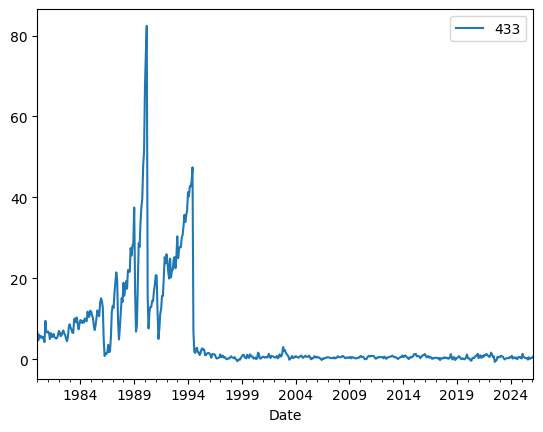

In [37]:
ipca.plot.line()

<Axes: >

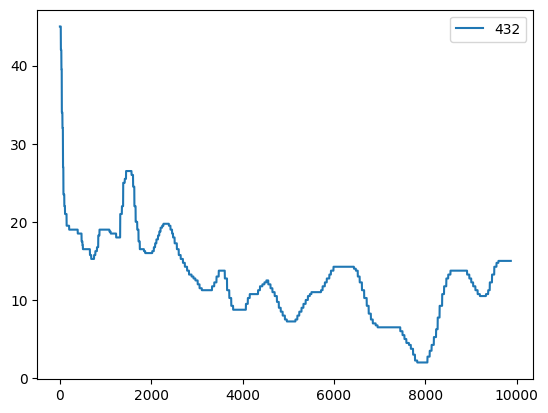

In [38]:
selic.plot.line()

<Axes: xlabel='Date'>

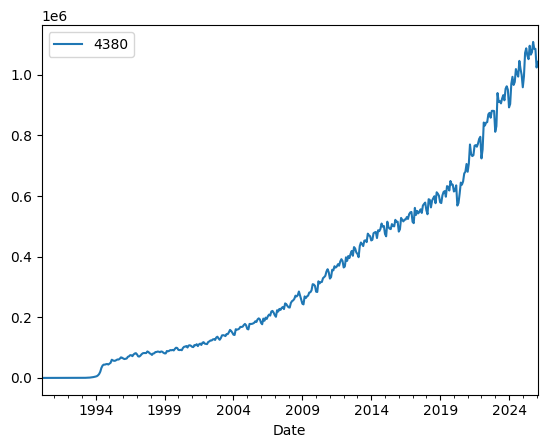

In [39]:
ibc_br.plot.line()

vamos deixar os 3 para começar em janeiro de 10/05/2004 porque foi quando a ANP começou a disponibilizar os preços domésticos da gasolina até 30/01/2026 que é a última data disponível para isso

In [40]:
# retirando multiindex
ipca = ipca.reset_index()
ibc_br = ibc_br.reset_index()

In [41]:
# transformando para datetime
selic['Date'] = pd.to_datetime(selic['Date'])
ipca['Date'] = pd.to_datetime(ipca['Date'])
ibc_br['Date'] = pd.to_datetime(ibc_br['Date'])

In [42]:
# agrupando por mẽs
ipca = (
    ipca
    .rename(columns={'433': 'ipca'})
    .groupby(pd.Grouper(key='Date', freq='ME'))
    .mean()
    .query('Date >= "2004-05-10" and Date <= "2026-01-01"')
)
selic = (
    selic
    .rename(columns={'432': 'selic'})
    .groupby(pd.Grouper(key='Date', freq='ME'))
    .mean()
    .query('Date >= "2004-05-10" and Date <= "2026-01-01"')
)
ibc_br = (
    ibc_br
    .rename(columns={'4380': 'ibc_br'})
    .groupby(pd.Grouper(key='Date', freq='ME'))
    .mean()
    .query('Date >= "2004-05-10" and Date <= "2026-01-01"')
)

<Axes: xlabel='Date'>

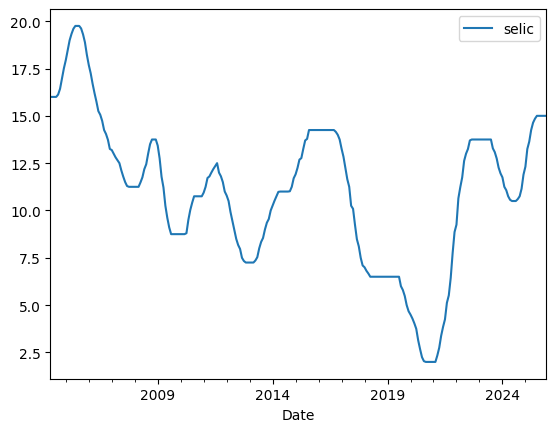

In [43]:
selic.plot()

In [44]:
ipca12 = ipca.rolling(12).sum().dropna() # deixamos o ipca pegando a soma da variação percentual dos últimos 12 meses
ibc_br12 = ibc_br.pct_change(12) * 100 # e aqui a variação anual dos últimos 12 meses
ibc_br12 = ibc_br12.dropna()
ipca12 = ipca12.query('Date >= "2005-05-31" and Date <= "2026-01-01"')
display(ipca12, ibc_br12)

,ipca
Date,
2005-05-31,7.77
2005-06-30,7.04
2005-07-31,6.38
2005-08-31,5.86
2005-09-30,5.88
...,...
2025-08-31,5.02
2025-09-30,5.06
2025-10-31,4.59


,ibc_br
Date,
2005-05-31,11.252991
2005-06-30,10.420683
2005-07-31,7.999696
2005-08-31,11.093274
2005-09-30,9.176741
...,...
2025-08-31,6.189054
2025-09-30,8.136850
2025-10-31,5.980075


In [45]:
selic

,selic
Date,
2004-05-31,16.000
2004-06-30,16.000
2004-07-31,16.000
2004-08-31,16.000
2004-09-30,16.125
...,...
2025-08-31,15.000
2025-09-30,15.000
2025-10-31,15.000


In [63]:
df_taxas = (
    selic
    .merge(ipca, on='Date')
    .merge(ibc_br, on='Date')
)
df_taxas['selic'] = df_taxas['selic'].round(2)
df_taxas['ibc_br'] = df_taxas['ibc_br'].round(2)
df_taxas

,selic,ipca,ibc_br
Date,,,
2004-05-31,16.00,0.51,160112.1
2004-06-30,16.00,0.71,162569.0
2004-07-31,16.00,0.91,168216.4
2004-08-31,16.00,0.69,168068.5
2004-09-30,16.12,0.33,168967.4
...,...,...,...
2025-08-31,15.00,-0.11,1066029.9
2025-09-30,15.00,0.48,1074352.8
2025-10-31,15.00,0.09,1107951.1


agora juntando com os preços da gasolina pegando dos dados da anp

In [47]:
import requests as re
url = 'https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/serie-historica-de-precos-de-combustiveis'
response = re.get(url)

In [48]:
from bs4 import BeautifulSoup
soup = BeautifulSoup(response.content, 'html.parser')
links = soup.find_all('a', href=lambda h: h and 'ca/ca' in h)
links

[<a class="internal-link" data-tippreview-enabled="false" data-tippreview-image="" data-tippreview-title="" href="https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/arquivos/shpc/dsas/ca/ca-2025-02.zip" target="_blank" title="">2º semestre de 2025</a>,
 <a class="internal-link" data-tippreview-enabled="true" data-tippreview-image="" data-tippreview-title="" href="https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/arquivos/shpc/dsas/ca/ca-2025-01.zip" target="_blank" title="">1º semestre de 2025</a>,
 <a class="internal-link" data-tippreview-enabled="true" data-tippreview-image="" data-tippreview-title="" href="https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/arquivos/shpc/dsas/ca/ca-2024-02.zip" target="_blank" title="">2º semestre de 2024</a>,
 <a class="internal-link" data-tippreview-enabled="false" data-tippreview-image="" data-tippreview-title="" href="https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/arquivos/shpc/dsas/ca/ca-2

In [49]:
import os

if not os.path.exists('gas_prices'):
    os.mkdir('gas_prices')

# baixando arquivos com preços da gasolina
for arquivo in links:
    url = arquivo.attrs['href']
    file_name = url.split('/')[-1]

    output_path = f'gas_prices/{file_name}'
    if os.path.exists(output_path):
        continue

    print(f"Arquivo atual: {file_name}")
    with re.get(url, stream=True) as response:
        response.raise_for_status()

        with open(output_path, "wb") as f:
            try:
                for chunk in response.iter_content(chunk_size=8192):
                    if chunk:
                        f.write(chunk)
            except:
                for chunk in response.iter_content(chunk_size=8192):
                    if chunk:
                        f.write(chunk)

print('Download concluído')

Download concluído


In [50]:
from glob import glob

df = pd.DataFrame()
files = glob('gas_prices/*')

for file in files:
    print(file)
    columns = ['Data da Coleta', 'Valor de Venda']
    df_temp = pd.read_csv(file, sep=';', encoding='latin-1').filter(columns).set_index('Data da Coleta')
    df = pd.concat([df, df_temp])

gas_prices\ca-2004-01.csv
gas_prices\ca-2004-02.csv
gas_prices\ca-2005-01.csv
gas_prices\ca-2005-02.csv
gas_prices\ca-2006-01.csv
gas_prices\ca-2006-02.csv
gas_prices\ca-2007-01.csv
gas_prices\ca-2007-02.csv
gas_prices\ca-2008-01.csv
gas_prices\ca-2008-02.csv
gas_prices\ca-2009-01.csv
gas_prices\ca-2009-02.csv
gas_prices\ca-2010-01.csv
gas_prices\ca-2010-02.csv
gas_prices\ca-2011-01.csv
gas_prices\ca-2011-02.csv
gas_prices\ca-2012-01.csv
gas_prices\ca-2012-02.csv
gas_prices\ca-2013-01.csv
gas_prices\ca-2013-02.csv
gas_prices\ca-2014-01.csv
gas_prices\ca-2014-02.csv
gas_prices\ca-2015-01.csv
gas_prices\ca-2015-02.csv
gas_prices\ca-2016-01.csv
gas_prices\ca-2016-02.csv
gas_prices\ca-2017-01.csv
gas_prices\ca-2017-02.csv
gas_prices\ca-2018-01.csv
gas_prices\ca-2018-02.csv
gas_prices\ca-2019-01.csv
gas_prices\ca-2019-02.csv
gas_prices\ca-2020-01.csv
gas_prices\ca-2020-02.csv


C:\Users\Usuario\AppData\Local\Temp\ipykernel_12632\2391425961.py:9: DtypeWarning: Columns (0: Valor de Compra) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(file, sep=';', encoding='latin-1').filter(columns).set_index('Data da Coleta')


gas_prices\ca-2021-01.csv
gas_prices\ca-2021-02.csv
gas_prices\ca-2022-02.zip
gas_prices\ca-2023-01.zip
gas_prices\ca-2023-02.zip
gas_prices\ca-2024-01.zip
gas_prices\ca-2024-02.zip
gas_prices\ca-2025-01.zip


C:\Users\Usuario\AppData\Local\Temp\ipykernel_12632\2391425961.py:9: DtypeWarning: Columns (0: ï»¿Regiao - Sigla, 1: Estado - Sigla, 2: Municipio, 3: Revenda, 4: CNPJ da Revenda, 5: Nome da Rua, 6: Numero Rua, 7: Complemento, 8: Bairro, 9: Cep, 10: Produto, 11: Data da Coleta, 12: Valor de Venda, 13: Unidade de Medida, 14: Bandeira) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(file, sep=';', encoding='latin-1').filter(columns).set_index('Data da Coleta')


gas_prices\ca-2025-02.zip


In [51]:
df.info()

<class 'pandas.DataFrame'>
Index: 18810364 entries, 11/05/2004 to 31/12/2025
Data columns (total 1 columns):
 #   Column          Dtype
---  ------          -----
 0   Valor de Venda  str  
dtypes: str(1)
memory usage: 287.0+ MB


In [52]:
df['Valor de Venda'] = df['Valor de Venda'].str.replace(',', '.')
df['Valor de Venda'] = df['Valor de Venda'].astype('float')

In [53]:
display(df.head())
display(df.info())

,Valor de Venda
Data da Coleta,
11/05/2004,1.967
11/05/2004,0.899
11/05/2004,1.299
10/05/2004,1.850
10/05/2004,0.780


<class 'pandas.DataFrame'>
Index: 18810364 entries, 11/05/2004 to 31/12/2025
Data columns (total 1 columns):
 #   Column          Dtype  
---  ------          -----  
 0   Valor de Venda  float64
dtypes: float64(1)
memory usage: 287.0+ MB


None

In [54]:
df.index = pd.to_datetime(df.index, format="%d/%m/%Y", errors="coerce")

df = df.dropna()

In [55]:
# aqui tiramos os valores que não conseguiram ser convertidos para data, como pequenos erros, tendo uma redução de (18810364 - 18801241)/18810364 = 4,8% dos dados

df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 18801241 entries, 2004-05-11 to 2025-12-31
Data columns (total 1 columns):
 #   Column          Dtype  
---  ------          -----  
 0   Valor de Venda  float64
dtypes: float64(1)
memory usage: 286.9 MB


In [56]:
df.head()

,Valor de Venda
Data da Coleta,
2004-05-11,1.967
2004-05-11,0.899
2004-05-11,1.299
2004-05-10,1.850
2004-05-10,0.780


In [57]:
# ajeitando preços para ficar mensalmente
df = (
    df
    .rename(columns={'Valor de Venda': 'preco_gasolina'})
    .reset_index()
    .groupby(pd.Grouper(key='Data da Coleta', freq='ME'))
    .mean()
    .interpolate(method='linear') # aqui perdemos 55 linhas ao agrupar ficando com 205 apenas, então vamos usar interpolação linear para ter os 260 meses
    .query('`Data da Coleta` >= "2004-05-10" and `Data da Coleta` <= "2026-01-01"')
)

In [58]:
display(df.head())
display(df.info())

,preco_gasolina
Data da Coleta,
2004-05-31,1.484687
2004-06-30,1.556904
2004-07-31,1.597016
2004-08-31,1.636072
2004-09-30,1.637797


<class 'pandas.DataFrame'>
DatetimeIndex: 260 entries, 2004-05-31 to 2025-12-31
Freq: ME
Data columns (total 1 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   preco_gasolina  260 non-null    float64
dtypes: float64(1)
memory usage: 4.1 KB


None

In [59]:
# transformando tudo em variação percentual
df['preco_gasolina_var'] = df['preco_gasolina'].pct_change(12) * 100
df = df.dropna()
df

,preco_gasolina,preco_gasolina_var
Data da Coleta,,
2005-05-31,1.814208,22.194639
2005-06-30,1.775512,14.041222
2005-07-31,1.785572,11.806812
2005-08-31,1.793754,9.637886
2005-09-30,1.903378,16.215763
...,...,...
2025-08-31,5.763437,1.180791
2025-09-30,5.778322,1.808567
2025-10-31,5.794255,2.010505


In [64]:
# juntando os dfs
df_taxas = df_taxas.merge(df[['preco_gasolina']], left_index=True, right_index=True)

In [66]:
df_taxas.to_csv('data.csv')